# Traffic Sign Data Exploration

Goal: 
- Understand data structure
- Identify preprocessing requirements
- Detect biases and edge cases

In [52]:
import pandas as pd
import cv2
import os
from zipfile import ZipFile
import matplotlib.pyplot as plt

In [50]:
data_path = '../data/traffic_Data.zip'

with ZipFile(data_path, 'r') as zip_ref:
    zip_ref.extractall('../data/')

In [44]:
dataset_path = '../data/traffic_Data/DATA'
label_path = '../data/labels.csv'

In [45]:
labels_df = pd.read_csv(label_path)

In [46]:
print(labels_df.head())
print("Num classes in CSV:", len(labels_df))

   ClassId                  Name
0        0   Speed limit (5km/h)
1        1  Speed limit (15km/h)
2        2  Speed limit (30km/h)
3        3  Speed limit (40km/h)
4        4  Speed limit (50km/h)
Num classes in CSV: 58


In [47]:
folders = sorted(os.listdir(dataset_path), key=lambda x: int(x))

print("Folders found:", len(folders))
print(folders[:10])

Folders found: 58
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [48]:
# Get valid image extensions
valid_ext = ('.png', '.jpg', '.jpeg')

# Count images per class
records = []

for _, row in labels_df.iterrows():
    class_id = row['ClassId']
    class_name = row['Name']
    
    folder_path = os.path.join(dataset_path, str(class_id))
    
    if not os.path.exists(folder_path):
        count = 0  # Missing folder
    else:
        files = os.listdir(folder_path)
        count = sum(f.lower().endswith(valid_ext) for f in files)
    
    records.append({
        "ClassId": class_id,
        "Name": class_name,
        "Count": count
    })

# Create DataFrame
main_df = pd.DataFrame(records)

# Sort for clarity
main_df = main_df.sort_values("ClassId").reset_index(drop=True)

main_df.head()

,ClassId,Name,Count
0,0,Speed limit (5km/h),118
1,1,Speed limit (15km/h),40
2,2,Speed limit (30km/h),80
3,3,Speed limit (40km/h),260
4,4,Speed limit (50km/h),98


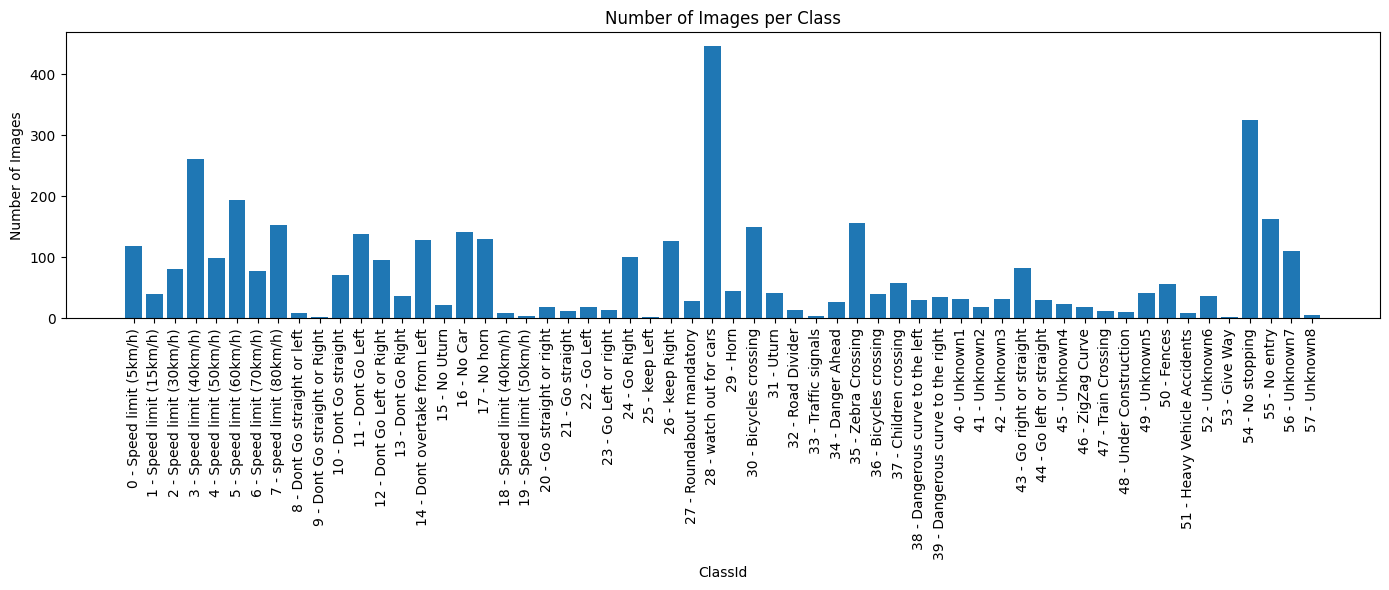

In [49]:
plt.figure(figsize=(14, 6))

plt.bar(main_df["ClassId"], main_df["Count"])

plt.xlabel("ClassId")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")

labels = main_df["ClassId"].astype(str) + " - " + main_df["Name"]

plt.xticks(main_df["ClassId"], labels, rotation=90)

plt.tight_layout()
plt.show()

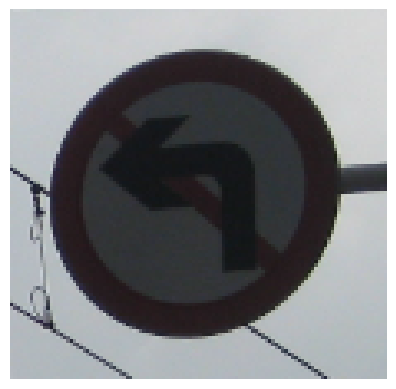

In [53]:
img_path = "../data/traffic_Data/DATA/11/011_0011.png"
img = cv2.imread(img_path)

if img is None:
    print("Error: Image not found. Check the file path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for Matplotlib
    plt.imshow(img)
    plt.axis("off")  # Hide axes
    plt.show()